In [138]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.metrics import silhouette_score

In [9]:
df = pd.read_csv("online_retail.csv")


In [10]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [11]:
df.shape

(541909, 8)

In [12]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [14]:
df.duplicated().sum()

np.int64(5268)

In [15]:
df[df.duplicated()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
...,...,...,...,...,...,...,...,...
541675,581538,22068,BLACK PIRATE TREASURE CHEST,1,2011-12-09 11:34:00,0.39,14446.0,United Kingdom
541689,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2011-12-09 11:34:00,2.49,14446.0,United Kingdom
541692,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,14446.0,United Kingdom
541699,581538,22694,WICKER STAR,1,2011-12-09 11:34:00,2.10,14446.0,United Kingdom


In [16]:
df1 = df.drop_duplicates(inplace = True)

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.shape

(536641, 8)

In [19]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
dtype: int64

In [20]:
df.head(8)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom


In [21]:
df2 = df.dropna().copy()

In [22]:
df2.shape

(401604, 8)

In [23]:
df2.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [24]:
df2.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [25]:
df2["InvoiceNo"].astype(str).str.startswith('C').sum()

np.int64(8872)

In [26]:
df2[df2["InvoiceNo"].astype(str).str.startswith('C')].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [27]:
df[df["StockCode"].astype(str).str.endswith('a')].head(15)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
5443,536862,84872a,TEATIME FUNKY FLOWER BACKPACK FOR 2,2,2010-12-03 11:13:00,11.02,NaN,United Kingdom
5448,536862,85039a,SET/4 RED MINI ROSE CANDLE IN BOWL,1,2010-12-03 11:13:00,3.36,NaN,United Kingdom
5672,536865,84559a,3D SHEET OF DOG STICKERS,1,2010-12-03 11:28:00,1.69,NaN,United Kingdom
5675,536865,84884a,ANT WHITE WIRE HEART SPIRAL,1,2010-12-03 11:28:00,8.47,NaN,United Kingdom
5677,536865,85014a,BLACK/BLUE POLKADOT UMBRELLA,2,2010-12-03 11:28:00,12.72,NaN,United Kingdom
5680,536865,85039a,SET/4 RED MINI ROSE CANDLE IN BOWL,1,2010-12-03 11:28:00,3.36,NaN,United Kingdom
6960,536982,85049a,TRADITIONAL CHRISTMAS RIBBONS,10,2010-12-03 14:27:00,3.36,NaN,United Kingdom
6964,536982,85123a,WHITE HANGING HEART T-LIGHT HOLDER,35,2010-12-03 14:27:00,6.77,NaN,United Kingdom
15773,537640,84989a,75 GREEN FAIRY CAKE CASES,1,2010-12-07 15:31:00,2.13,NaN,United Kingdom
15777,537640,85049a,TRADITIONAL CHRISTMAS RIBBONS,55,2010-12-07 15:31:00,3.36,NaN,United Kingdom


In [28]:
df2['StockCode'].value_counts()

StockCode
85123A    2065
22423     1894
85099B    1659
47566     1409
84879     1405
          ... 
90181A       1
90199B       1
90102        1
84550        1
90214O       1
Name: count, Length: 3684, dtype: int64

In [29]:
df2["Description"].value_counts()

Description
WHITE HANGING HEART T-LIGHT HOLDER     2058
REGENCY CAKESTAND 3 TIER               1894
JUMBO BAG RED RETROSPOT                1659
PARTY BUNTING                          1409
ASSORTED COLOUR BIRD ORNAMENT          1405
                                       ... 
LETTER "W" BLING KEY RING                 1
CROCHET LILAC/RED BEAR KEYRING            1
MIDNIGHT BLUE CRYSTAL DROP EARRINGS       1
BLACK VINT ART DEC CRYSTAL BRACELET       1
WHITE STONE/CRYSTAL EARRINGS              1
Name: count, Length: 3896, dtype: int64

In [155]:
df2.sort_values(by="Quantity", ascending=False).head(10)


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,Date,Time
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,16446.0,United Kingdom,2011-12-09,09:15:00
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,12346.0,United Kingdom,2011-01-18,10:01:00
502122,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,0.00,13256.0,United Kingdom,2011-11-25,15:57:00
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,0.21,12901.0,United Kingdom,2011-10-27,12:26:00
206121,554868,22197,SMALL POPCORN HOLDER,4300,0.72,13135.0,United Kingdom,2011-05-27,10:52:00
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,0.82,18087.0,United Kingdom,2011-02-22,10:43:00
270885,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,0.06,14609.0,United Kingdom,2011-07-19,17:04:00
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,15749.0,United Kingdom,2011-04-18,13:20:00
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,15749.0,United Kingdom,2011-01-11,12:55:00
433788,573995,16014,SMALL CHINESE STYLE SCISSOR,3000,0.32,16308.0,United Kingdom,2011-11-02,11:24:00


In [156]:
df2[df2['Quantity'] == 80995]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,Date,Time
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,16446.0,United Kingdom,2011-12-09,09:15:00


In [157]:
df2[df2['Quantity' ] == 0]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,Date,Time


In [158]:
df2[df2['Quantity' ] <= 0]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,Date,Time


In [159]:
df2[df2['UnitPrice' ] <= 0.00]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,Date,Time
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,0.0,12647.0,Germany,2010-12-05,14:02:00
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,0.0,16560.0,United Kingdom,2010-12-16,14:36:00
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,0.0,14911.0,EIRE,2010-12-21,13:45:00
47068,540372,22090,PAPER BUNTING RETROSPOT,24,0.0,13081.0,United Kingdom,2011-01-06,16:41:00
47070,540372,22553,PLASTERS IN TIN SKULLS,24,0.0,13081.0,United Kingdom,2011-01-06,16:41:00
56674,541109,22168,ORGANISER WOOD ANTIQUE WHITE,1,0.0,15107.0,United Kingdom,2011-01-13,15:10:00
86789,543599,84535B,FAIRY CAKES NOTEBOOK A6 SIZE,16,0.0,17560.0,United Kingdom,2011-02-10,13:08:00
130188,547417,22062,CERAMIC BOWL WITH LOVE HEART DESIGN,36,0.0,13239.0,United Kingdom,2011-03-23,10:25:00
139453,548318,22055,MINI CAKE STAND HANGING STRAWBERY,5,0.0,13113.0,United Kingdom,2011-03-30,12:45:00
145208,548871,22162,HEART GARLAND RUSTIC PADDED,2,0.0,14410.0,United Kingdom,2011-04-04,14:42:00


In [160]:
df2['CustomerID'].value_counts()

CustomerID
17841.0    7676
14911.0    5672
14096.0    5111
12748.0    4413
14606.0    2677
           ... 
13256.0       1
18174.0       1
13017.0       1
13747.0       1
15195.0       1
Name: count, Length: 4339, dtype: int64

In [161]:
df2.head()

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,Date,Time
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850.0,United Kingdom,2010-12-01,08:26:00
1,536365,71053,WHITE METAL LANTERN,6,3.39,17850.0,United Kingdom,2010-12-01,08:26:00
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850.0,United Kingdom,2010-12-01,08:26:00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850.0,United Kingdom,2010-12-01,08:26:00
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850.0,United Kingdom,2010-12-01,08:26:00


In [162]:
df2[df['CustomerID'] == 0]

C:\Users\Mahendiran\AppData\Local\Temp\ipykernel_29456\3028995142.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df2[df['CustomerID'] == 0]


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,Date,Time


In [163]:
df2['Country'].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Finland',
       'Austria', 'Greece', 'Singapore', 'Lebanon',
       'United Arab Emirates', 'Israel', 'Saudi Arabia', 'Czech Republic',
       'Canada', 'Unspecified', 'Brazil', 'USA', 'European Community',
       'Bahrain', 'Malta', 'RSA'], dtype=object)

In [ ]:
df2['InvoiceDate'].dtype

In [ ]:
df2.shape

In [ ]:
df2['Date'] = df2['InvoiceDate'].dt.date

In [ ]:
df2.drop(columns = ['InvoiceDate'],inplace = True)

In [ ]:
df2 = df2[df2['Quantity'] >0.0].copy()

In [ ]:
df2.shape

In [166]:
df3 = df2[(df2['StockCode'] != "M") & (df2['StockCode'] != "D")  ].copy()

In [167]:
df3.shape

(392447, 9)

In [168]:
df4 = df3[~(df3['UnitPrice'] <= 0.00)].copy()

In [169]:
df4.head(10)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,Date,Time
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850.0,United Kingdom,2010-12-01,08:26:00
1,536365,71053,WHITE METAL LANTERN,6,3.39,17850.0,United Kingdom,2010-12-01,08:26:00
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850.0,United Kingdom,2010-12-01,08:26:00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850.0,United Kingdom,2010-12-01,08:26:00
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850.0,United Kingdom,2010-12-01,08:26:00
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,7.65,17850.0,United Kingdom,2010-12-01,08:26:00
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,4.25,17850.0,United Kingdom,2010-12-01,08:26:00
7,536366,22633,HAND WARMER UNION JACK,6,1.85,17850.0,United Kingdom,2010-12-01,08:28:00
8,536366,22632,HAND WARMER RED POLKA DOT,6,1.85,17850.0,United Kingdom,2010-12-01,08:28:00
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,1.69,13047.0,United Kingdom,2010-12-01,08:34:00


In [170]:
df4["StockCode"].value_counts()

StockCode
85123A    2023
22423     1713
85099B    1615
84879     1395
47566     1389
          ... 
84206B       1
90212B       1
35597B       1
84613C       1
84802A       1
Name: count, Length: 3664, dtype: int64

In [171]:
no_alpha_end = df4[df4['StockCode'].str.match(r'^\d+$')]

len(no_alpha_end)


358277

In [172]:
alpha_end = df4[df4['StockCode'].str[-1].str.isalpha()]

alpha_end.shape


(34003, 9)

In [173]:
df4.head(10)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,Date,Time
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850.0,United Kingdom,2010-12-01,08:26:00
1,536365,71053,WHITE METAL LANTERN,6,3.39,17850.0,United Kingdom,2010-12-01,08:26:00
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850.0,United Kingdom,2010-12-01,08:26:00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850.0,United Kingdom,2010-12-01,08:26:00
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850.0,United Kingdom,2010-12-01,08:26:00
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,7.65,17850.0,United Kingdom,2010-12-01,08:26:00
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,4.25,17850.0,United Kingdom,2010-12-01,08:26:00
7,536366,22633,HAND WARMER UNION JACK,6,1.85,17850.0,United Kingdom,2010-12-01,08:28:00
8,536366,22632,HAND WARMER RED POLKA DOT,6,1.85,17850.0,United Kingdom,2010-12-01,08:28:00
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,1.69,13047.0,United Kingdom,2010-12-01,08:34:00


In [174]:
alpha_end2 = df4[df4['InvoiceNo'].str.isalpha()]

alpha_end2.shape


(0, 9)

In [175]:
print("Negative Quantity:", (df4['Quantity'] < 0).sum())
print("Zero or Negative Price:", (df4['UnitPrice'] <= 0).sum())


Negative Quantity: 0
Zero or Negative Price: 0


In [176]:
print("Unique Customers:", df4['CustomerID'].nunique())
print("Unique StockCodes:", df4['StockCode'].nunique())
print("Unique Invoices:", df4['InvoiceNo'].nunique())


Unique Customers: 4335
Unique StockCodes: 3664
Unique Invoices: 18468


In [177]:
print("Min Date:", df4['Date'].min())
print("Max Date:", df4['Date'].max())


Min Date: 2010-12-01
Max Date: 2011-12-09


In [178]:
df5 = df4[df4['StockCode'] != 'BANK CHARGES'].copy()


In [179]:
df5[df5['StockCode'] == 'Post']

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,Date,Time


In [180]:
df5.head()

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,Date,Time
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850.0,United Kingdom,2010-12-01,08:26:00
1,536365,71053,WHITE METAL LANTERN,6,3.39,17850.0,United Kingdom,2010-12-01,08:26:00
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850.0,United Kingdom,2010-12-01,08:26:00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850.0,United Kingdom,2010-12-01,08:26:00
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850.0,United Kingdom,2010-12-01,08:26:00


In [181]:
df5['Spending $'] = df['Quantity']*df['UnitPrice']

In [182]:
df5.drop(columns = ['Description'], inplace = True)

In [183]:
df5.head()

,InvoiceNo,StockCode,Quantity,UnitPrice,CustomerID,Country,Date,Time,Spending $
0,536365,85123A,6,2.55,17850.0,United Kingdom,2010-12-01,08:26:00,15.30
1,536365,71053,6,3.39,17850.0,United Kingdom,2010-12-01,08:26:00,20.34
2,536365,84406B,8,2.75,17850.0,United Kingdom,2010-12-01,08:26:00,22.00
3,536365,84029G,6,3.39,17850.0,United Kingdom,2010-12-01,08:26:00,20.34
4,536365,84029E,6,3.39,17850.0,United Kingdom,2010-12-01,08:26:00,20.34


In [184]:
last_purchase = df5.groupby('CustomerID')['Date'].max().reset_index()


In [185]:
snapshot_date = df5['Date'].max() + pd.Timedelta(days=1)


In [186]:
last_purchase['Date'] = pd.to_datetime(last_purchase['Date'])


In [187]:
df5['Date'] = pd.to_datetime(df5['Date'])


In [188]:
snapshot_date = df5['Date'].max() + pd.Timedelta(days=1)
df5['Recency'] = (snapshot_date - last_purchase['Date']).dt.days


In [189]:
df5.head()

,InvoiceNo,StockCode,Quantity,UnitPrice,CustomerID,Country,Date,Time,Spending $,Recency
0,536365,85123A,6,2.55,17850.0,United Kingdom,2010-12-01,08:26:00,15.30,326.0
1,536365,71053,6,3.39,17850.0,United Kingdom,2010-12-01,08:26:00,20.34,3.0
2,536365,84406B,8,2.75,17850.0,United Kingdom,2010-12-01,08:26:00,22.00,76.0
3,536365,84029G,6,3.39,17850.0,United Kingdom,2010-12-01,08:26:00,20.34,19.0
4,536365,84029E,6,3.39,17850.0,United Kingdom,2010-12-01,08:26:00,20.34,311.0


In [190]:
df4.sample(5)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,Date,Time
91758,544151,22082,RIBBON REEL STRIPES DESIGN,5,1.65,15024.0,United Kingdom,2011-02-16,12:02:00
180796,552357,22771,CLEAR DRAWER KNOB ACRYLIC EDWARDIAN,12,1.25,18219.0,United Kingdom,2011-05-09,12:16:00
395612,571039,21774,DECORATIVE CATS BATHROOM BOTTLE,1,1.25,16121.0,United Kingdom,2011-10-13,12:59:00
323862,565366,23356,LOVE HOT WATER BOTTLE,3,5.95,17091.0,United Kingdom,2011-09-02,14:56:00
379058,569672,21498,RED RETROSPOT WRAP,25,0.42,17841.0,United Kingdom,2011-10-05,13:58:00


In [191]:
df4[df4['CustomerID'] == 17850.0]['Date'].value_counts()

Date
2010-12-02    213
2010-12-01     84
Name: count, dtype: int64

In [192]:
df4[df4['CustomerID'] == 13505.0]['Date'].value_counts()

Date
2011-09-28    92
2011-04-21    54
2011-05-31    42
2011-06-26    27
Name: count, dtype: int64

In [193]:
df4["TotalPrice"] = df4["Quantity"] * df4["UnitPrice"]

In [194]:
snapshot_date = df4["Date"].max() + pd.Timedelta(days=1)
rfm = df4.groupby("CustomerID").agg({
    "Date": lambda x: (snapshot_date - x.max()).days,  # Recency
    "InvoiceNo": "count",                                     # Frequency
    "TotalPrice": "sum"                                       # Monetary
})

rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm = rfm.reset_index()

In [195]:
type(rfm)

pandas.core.frame.DataFrame

In [196]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,3,182,4310.00
2,12348.0,76,31,1797.24
3,12349.0,19,73,1757.55
4,12350.0,311,17,334.40


In [197]:
df4.head()

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,Date,Time,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850.0,United Kingdom,2010-12-01,08:26:00,15.30
1,536365,71053,WHITE METAL LANTERN,6,3.39,17850.0,United Kingdom,2010-12-01,08:26:00,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850.0,United Kingdom,2010-12-01,08:26:00,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850.0,United Kingdom,2010-12-01,08:26:00,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850.0,United Kingdom,2010-12-01,08:26:00,20.34


In [198]:
rfm.shape

(4335, 4)

In [199]:
rfm


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,3,182,4310.00
2,12348.0,76,31,1797.24
3,12349.0,19,73,1757.55
4,12350.0,311,17,334.40
...,...,...,...,...
4330,18280.0,278,10,180.60
4331,18281.0,181,7,80.82
4332,18282.0,8,12,178.05
4333,18283.0,4,719,2039.58


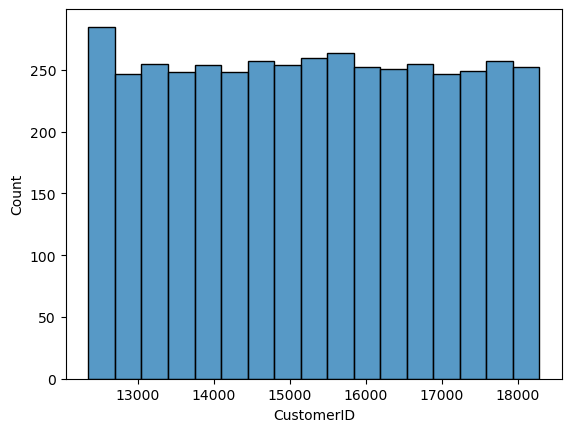

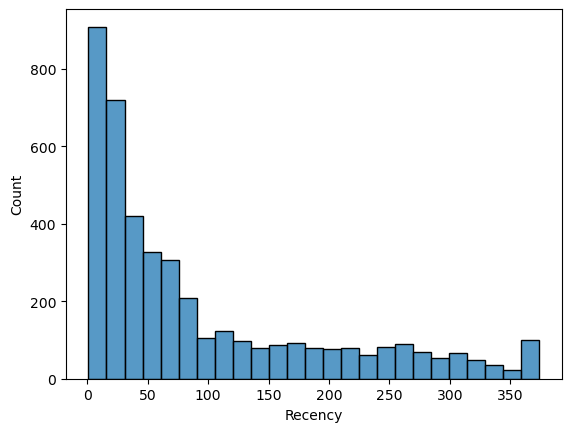

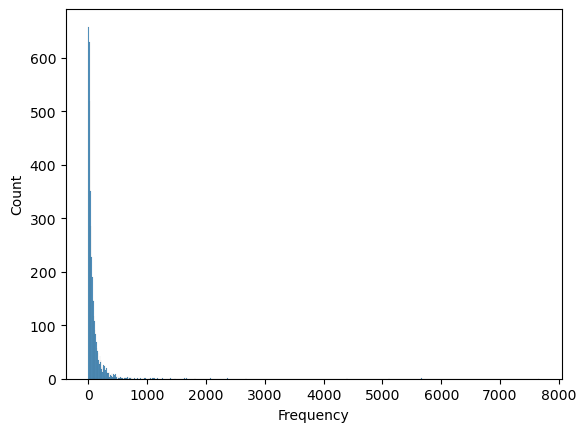

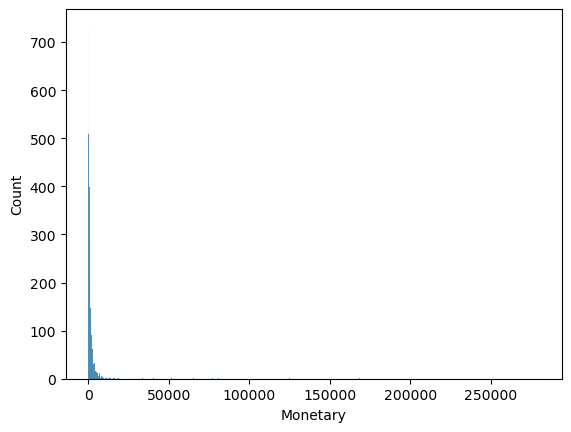

In [200]:
for col in rfm.columns:
    sns.histplot(x = rfm[col])
    plt.xlabel(f"{col}")
    plt.show()

In [201]:
X = rfm[["Recency","Frequency","Monetary"]]

In [202]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [203]:
X_scaled

array([[ 2.32355546e+00, -3.97239974e-01,  8.38194684e+00],
       [-9.00309877e-01,  4.05919151e-01,  2.53448608e-01],
       [-1.71696349e-01, -2.64119677e-01, -2.68307413e-02],
       ...,
       [-8.50404841e-01, -3.48429198e-01, -2.07439124e-01],
       [-8.90328870e-01,  2.78877247e+00,  2.00450516e-04],
       [-5.01069587e-01, -9.10632909e-02, -2.23645825e-02]])

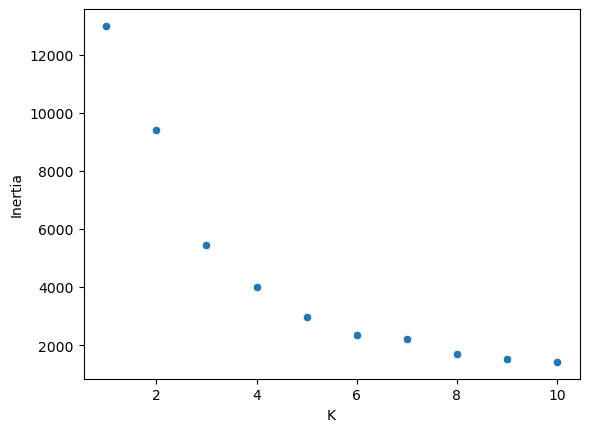

In [204]:
inertia = []

for k in range(1,11):
    kmeans = KMeans(n_clusters = k, random_state = 34)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

sns.scatterplot(x = range(1,11), y = inertia, )
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

In [205]:
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    print(k, silhouette_score(X_scaled, labels))

2 0.5774505164022962
3 0.6027964096088168
4 0.6036916046549442
5 0.6145720240591017
6 0.5902331288264954
7 0.5296579902827265
8 0.5167547711195686
9 0.42298104914686396
10 0.4304584718031783


In [218]:
best_k = 5

kmeans = KMeans(n_clusters = best_k, random_state = 1)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)

In [219]:
rfm.sample(5)

,CustomerID,Recency,Frequency,Monetary,Cluster
181,12574.0,316,11,218.45,1
3953,17757.0,2,739,5589.44,0
2043,15134.0,15,73,1387.99,2
3996,17824.0,52,13,298.40,2
2530,15789.0,359,25,351.30,1


In [220]:
rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,16.278689,477.733607,11769.968074
1,250.118147,27.510397,490.156305
2,44.782335,72.425074,1330.078655
3,2.500000,5711.000000,69413.097500
4,8.000000,825.833333,190808.536667


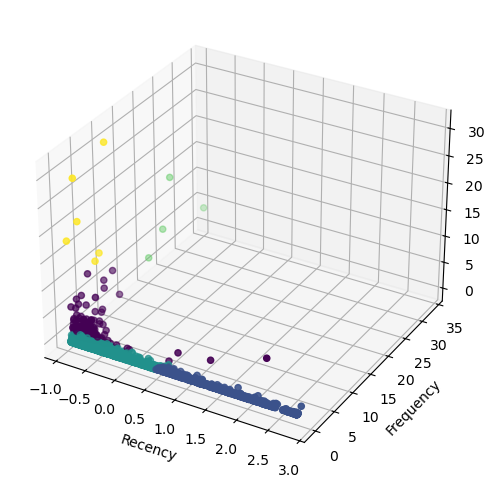

In [221]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_scaled[:,0], 
    X_scaled[:,1], 
    X_scaled[:,2], 
    c=rfm['Cluster'], 
    cmap='viridis'
)

ax.set_xlabel("Recency")
ax.set_ylabel("Frequency")
ax.set_zlabel("Monetary")

plt.show()

In [216]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

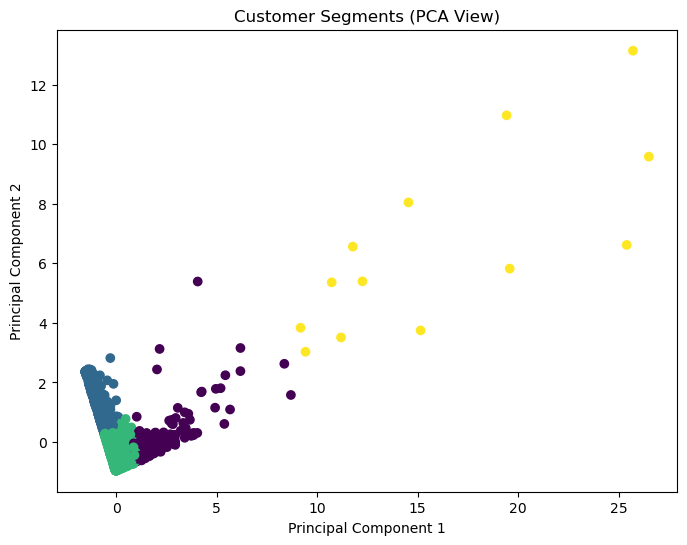

In [217]:
plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0], 
    X_pca[:,1], 
    c=rfm['Cluster'], 
    cmap='viridis'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segments (PCA View)")
plt.show()

In [225]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()
cluster_percent = round((cluster_counts / len(rfm)) * 100, 2)

report = pd.DataFrame({
    "Customers": cluster_counts,
    "Percentage (%)": cluster_percent
})

report

,Customers,Percentage (%)
Cluster,,
0,244,5.63
1,1058,24.41
2,3023,69.73
3,4,0.09
4,6,0.14


In [226]:
profile = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(2)
profile

,Recency,Frequency,Monetary
Cluster,,,
0,16.28,477.73,11769.97
1,250.12,27.51,490.16
2,44.78,72.43,1330.08
3,2.50,5711.00,69413.10
4,8.00,825.83,190808.54


In [227]:
final_report = profile.merge(report, left_index=True, right_index=True)
final_report

,Recency,Frequency,Monetary,Customers,Percentage (%)
Cluster,,,,,
0,16.28,477.73,11769.97,244,5.63
1,250.12,27.51,490.16,1058,24.41
2,44.78,72.43,1330.08,3023,69.73
3,2.50,5711.00,69413.10,4,0.09
4,8.00,825.83,190808.54,6,0.14


In [228]:
rfm.groupby('Cluster')['Monetary'].sum()

Cluster
0    2871872.210
1     518585.371
2    4020827.773
3     277652.390
4    1144851.220
Name: Monetary, dtype: float64

In [229]:
total_revenue = rfm['Monetary'].sum()

revenue_report = rfm.groupby('Cluster')['Monetary'].sum().to_frame()
revenue_report['Revenue %'] = round(
    revenue_report['Monetary'] / total_revenue * 100, 2
)

revenue_report

,Monetary,Revenue %
Cluster,,
0,2871872.210,32.51
1,518585.371,5.87
2,4020827.773,45.52
3,277652.390,3.14
4,1144851.220,12.96
